# The Appetite Gauge — a quantitative teardown \U0001F52C
### Rolling-beta neutralisation · a three-way horse race · horizon-lag HAC · planted-factor control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The study turns
on one regression: put the raw gauge, its beta-neutral residual and the market's own trailing
return in the same equation and see which one keeps its *t*-statistic.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md). The sample is fifteen years — SPHB and SPLV
> launched in 2011 — and that limit is quoted next to every statistic.
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from appetite import data, strategy as st

px = data.load_prices()
rets = st.to_returns(px)
common = rets[list(data.TICKERS)].dropna()
sig = st.build_signals(common, data.HIGH_BETA, data.LOW_VOL, data.MARKET)
sb = st.spread_beta(common, data.HIGH_BETA, data.LOW_VOL, data.MARKET)
print(f"as-of {data.AS_OF} | {common.index[0].date()} -> {common.index[-1].date()} "
      f"({len(common) / 252:.1f} years)")
print(f"beta of {data.HIGH_BETA}: {sb['beta_high']:+.2f}   "
      f"beta of {data.LOW_VOL}: {sb['beta_low']:+.2f}   "
      f"beta of the spread: {sb['beta_of_spread']:+.2f}   R2 on the market: "
      f"{sb['r2_on_market']:.0%}")

as-of 2026-06-30 | 2011-06-02 -> 2026-06-30 (15.0 years)
beta of SPHB: +1.42   beta of SPLV: +0.68   beta of the spread: +0.74   R2 on the market: 35%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | The gauge is **35% explained by the market itself** — the high-beta minus low-volatility spread carries a beta of **+0.74** to the index, so a rising gauge is very largely a rising market. On its own the raw spread's trailing 63-day average predicts the next 21 days with *t* = **-0.68**; once it is beta-neutralised that falls to **+2.21**, and in the decomposition where it competes with the market component it is **+3.55** against the market's -3.71. Across the 27 lookback × horizon × signal cells, 14 clear |*t*| = 2 against 1.4 expected by luck — and the sample is only 15 years long, which caps what any of these numbers can mean. |
| **Tradability** | Fragile | The rule — own the index while the gauge is positive, hold bills otherwise — was invested 57% of the time, switched 12.4 times a year and returned **+10.63%/yr** against **+15.10%** for holding the index (-4.46%/yr; Sharpe +1.11 vs +0.92, *t* = -1.36). Its worst drawdown was -19.4% against -33.7% — the familiar trade of return for a shallower hole, available from any trend filter. |

> \U0001F4A1 **In plain words.** Most of the gauge is the market. The part that is not is too
> small to measure in fifteen years.

## 1 · The claim, made testable

- **H₁ (confound).** The raw spread's R² on the contemporaneous market return is large, and its
  beta is approximately β(SPHB) − β(SPLV).
- **H₂ (raw prediction).** The trailing raw spread predicts the market's next-month return.
- **H₃ (the real test).** The **beta-neutral** residual predicts it too, and keeps its
  *t*-statistic in the decomposition regression that also contains the market component.
  (Note the shape of that regression: since `raw = beta_neutral + β · market` identically, all
  three cannot be regressors at once — the design matrix would be singular. The decomposition
  is the non-degenerate way to ask the same question.)
- **H₄ (tradability).** The implied rule beats buy-and-hold after costs.

## 2 · The neutralisation, and its own assumption

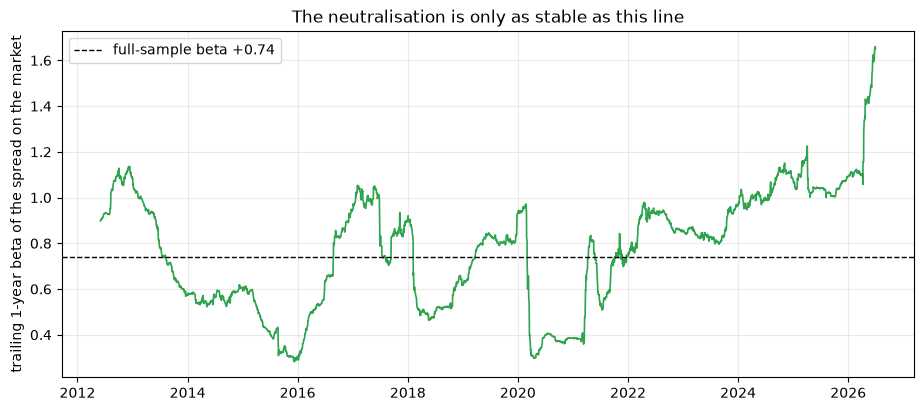

count   3,539.0000
mean        0.7700
std         0.2510
min         0.2820
25%         0.5590
50%         0.8130
75%         0.9640
max         1.6600


In [3]:
b = st.rolling_beta(st.ratio_raw(common, data.HIGH_BETA, data.LOW_VOL),
                    common[data.MARKET], window=252)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(b.index, b, lw=1.2, color="#2ea44f")
ax.axhline(sb["beta_of_spread"], color="k", ls="--", lw=1,
           label=f"full-sample beta {sb['beta_of_spread']:+.2f}")
ax.set_ylabel("trailing 1-year beta of the spread on the market"); ax.legend()
ax.set_title("The neutralisation is only as stable as this line")
plt.show()
print(b.describe().round(3).to_string())

## 3 · The teardown

### 3.1 The full grid

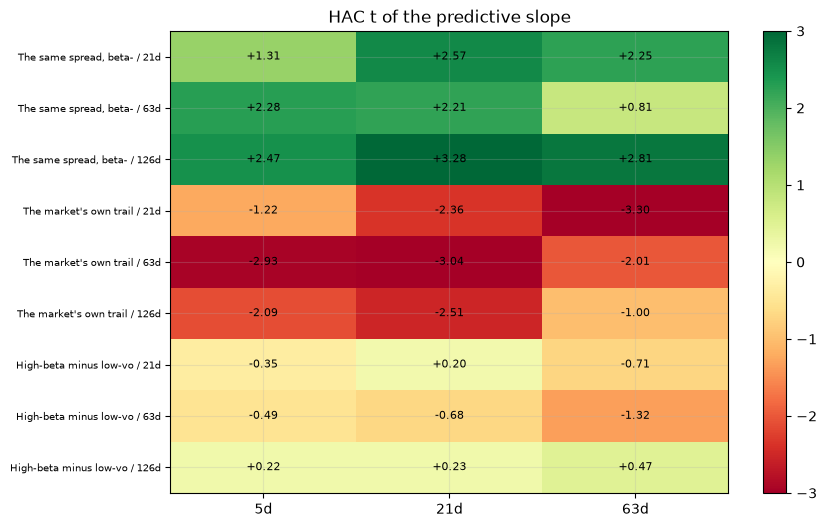

14 of 27 cells clear |t| = 2; luck gives 1.35


In [4]:
grid = st.univariate_grid(sig, common[data.MARKET])
piv = grid.pivot_table(index=["signal", "lookback"], columns="horizon", values="t")
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=-3, vmax=3, aspect="auto")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels([f"{c}d" for c in piv.columns])
ax.set_yticks(range(piv.shape[0]))
ax.set_yticklabels([f"{st.SIGNAL_LABEL[a][:22]} / {b}d" for a, b in piv.index], fontsize=7)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i, j]:+.2f}", ha="center", va="center", fontsize=8)
ax.set_title("HAC t of the predictive slope")
fig.colorbar(im, ax=ax)
plt.show()
print(f"{int((grid['t'].abs() >= 2).sum())} of {len(grid)} cells clear |t| = 2; "
      f"luck gives {st.expected_false_positives(len(grid)):.2f}")

### 3.2 The regression that settles it

In [5]:
for lb, hz in ((21, 5), (63, 21), (126, 63)):
    race = st.horse_race(sig, common[data.MARKET], lookback=lb, horizon=hz)
    print(f"--- lookback {lb}d, horizon {hz}d ---")
    print(race.round(4).to_string(index=False))
    print()

--- lookback 21d, horizon 5d ---
     specification       signal    beta       t     r2
         raw alone          raw -0.1107 -0.3484 0.0002
beta_neutral alone beta_neutral  0.4006  1.3142 0.0017
market_trend alone market_trend -0.7891 -1.2229 0.0051
 the decomposition beta_neutral  0.4688  1.5246 0.0059
 the decomposition market_trend -0.7052 -0.9976 0.0059



--- lookback 63d, horizon 21d ---
     specification       signal     beta       t     r2
         raw alone          raw  -1.0998 -0.6843 0.0018
beta_neutral alone beta_neutral   3.8679  2.2052 0.0131
market_trend alone market_trend  -9.2669 -3.0405 0.0469
 the decomposition beta_neutral   6.4710  3.5535 0.0800
 the decomposition market_trend -11.7739 -3.7067 0.0800



--- lookback 126d, horizon 63d ---
     specification       signal     beta       t     r2
         raw alone          raw   2.3797  0.4700 0.0015
beta_neutral alone beta_neutral  12.1699  2.8120 0.0279
market_trend alone market_trend -12.3714 -1.0020 0.0139
 the decomposition beta_neutral  14.8857  3.0580 0.0466
 the decomposition market_trend -14.8748 -1.1386 0.0466



> \U0001F4A1 **In plain words.** Read the "the decomposition" rows. The raw gauge has been split
> into exactly two pieces — the market, and everything else — and they are competing for the
> same slope. If the "everything else" piece keeps a *t*, the desks are right. If it does not,
> the gauge is the market's own trend wearing a costume.

### 3.3 The rule, all three signals, swept

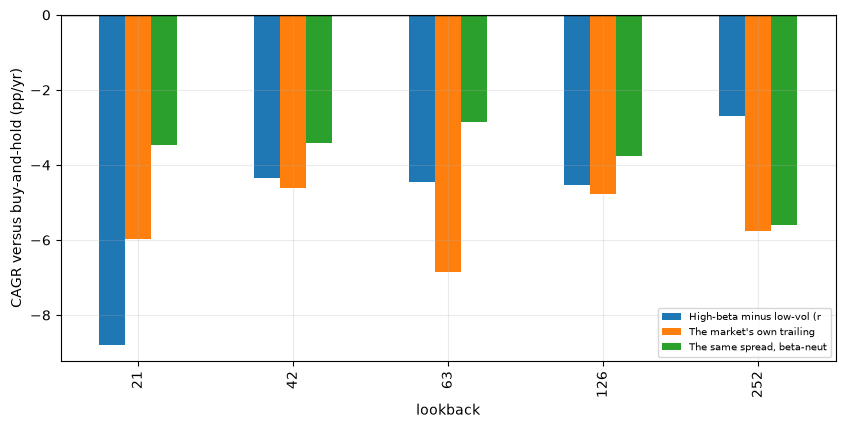

"                    signal  lookback  cagr_gap  sharpe_gap  time_invested       t\nHigh-beta minus low-vol (r        21   -0.0879     -0.2597         0.5267 -2.4512\nHigh-beta minus low-vol (r        42   -0.0434      0.1693         0.5573 -1.3243\nHigh-beta minus low-vol (r        63   -0.0446      0.1878         0.5664 -1.3592\nHigh-beta minus low-vol (r       126   -0.0452      0.1203         0.6077 -1.4099\nHigh-beta minus low-vol (r       252   -0.0269      0.3307         0.6209 -0.9055\nThe same spread, beta-neut        21   -0.0347      0.1073         0.4498 -1.1591\nThe same spread, beta-neut        42   -0.0340      0.1789         0.4666 -1.1025\nThe same spread, beta-neut        63   -0.0286      0.3466         0.4438 -0.9319\nThe same spread, beta-neut       126   -0.0376      0.2387         0.3852 -1.1422\nThe same spread, beta-neut       252   -0.0561      0.2347         0.3485 -1.4756\nThe market's own trailing         21   -0.0597     -0.0493         0.6969 -1.7871\nThe

In [6]:
rows = []
for name in st.SIGNALS:
    for lb in (21, 42, 63, 126, 252):
        r = st.timing_rule(common, sig[name], data.MARKET, data.CASH, lookback=lb,
                           cost_bps=2.0)
        rows.append({"signal": st.SIGNAL_LABEL[name][:26], "lookback": lb,
                     "cagr_gap": r["cagr_gap"], "sharpe_gap": r["sharpe_gap"],
                     "time_invested": r["time_invested"], "t": r["t_gap"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot(index="lookback", columns="signal", values="cagr_gap").mul(100).plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("CAGR versus buy-and-hold (pp/yr)"); ax.legend(fontsize=7, title="")
plt.show()
d.round(4).to_string(index=False)

### 3.4 Drawdown by drawdown

In [7]:
for name in ("raw", "beta_neutral"):
    print(f"--- {st.SIGNAL_LABEL[name]} ---")
    print(st.crisis_table(sig[name], common[data.MARKET], lookback=63).to_string())
    print()

--- High-beta minus low-vol (raw) ---
                       market_peak signal_turned_negative  sessions_of_warning  drawdown
episode                                                                                 
2015 China devaluation  2015-07-20             2015-07-01                   13   -0.1191
2018 Q4                 2018-09-20             2018-09-04                   12   -0.1935
COVID crash             2020-02-19             2020-02-10                    7   -0.3372
2022 bear market        2022-01-03             2021-12-13                   15   -0.2450

--- The same spread, beta-neutralised ---
                       market_peak signal_turned_negative  sessions_of_warning  drawdown
episode                                                                                 
2015 China devaluation  2015-07-20             2015-07-01                   13   -0.1191
2018 Q4                 2018-09-20             2018-09-04                   12   -0.1935
COVID crash             2020-

### 3.5 Other pairs, same test

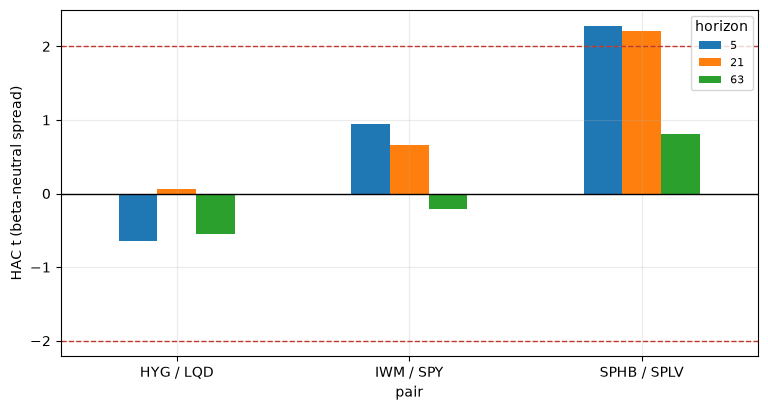

'       pair  horizon       t     r2\nSPHB / SPLV        5  2.2796 0.0052\nSPHB / SPLV       21  2.2052 0.0131\nSPHB / SPLV       63  0.8136 0.0030\n  IWM / SPY        5  0.9502 0.0014\n  IWM / SPY       21  0.6563 0.0021\n  IWM / SPY       63 -0.2080 0.0005\n  HYG / LQD        5 -0.6402 0.0005\n  HYG / LQD       21  0.0641 0.0000\n  HYG / LQD       63 -0.5497 0.0033'

In [8]:
rows = []
for label, (hi, lo) in {"SPHB / SPLV": (data.HIGH_BETA, data.LOW_VOL),
                        "IWM / SPY": ("IWM", "SPY"),
                        "HYG / LQD": ("HYG", "LQD")}.items():
    s2 = st.ratio_beta_neutral(common, hi, lo, data.MARKET)
    for hz in st.HORIZONS:
        r = st.hac_regression(st.forward_return(common[data.MARKET], hz),
                              st.trailing(s2, 63).to_frame("x"), lags=hz)
        rows.append({"pair": label, "horizon": hz, "t": r.get("t_x", np.nan),
                     "r2": r.get("r2", np.nan)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
d.pivot(index="pair", columns="horizon", values="t").plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("HAC t (beta-neutral spread)"); ax.legend(title="horizon", fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
d.round(4).to_string(index=False)

### 3.6 The synthetic control

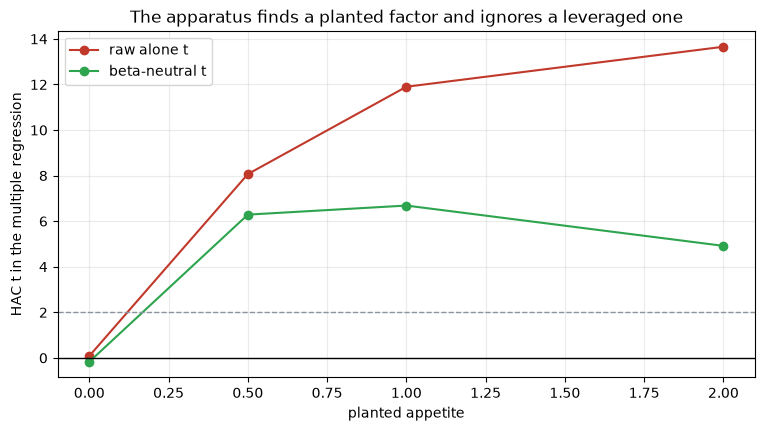

,raw alone t,beta-neutral t
planted appetite,,
0.0000,0.0840,-0.1700
0.5000,8.0670,6.2880
1.0000,11.9000,6.6860
2.0000,13.6560,4.9170


In [9]:
rows = []
for strength in (0.0, 0.5, 1.0, 2.0):
    raw_t, neu_t = [], []
    for s in range(6):
        sim = st.synthetic_world(n=4000, appetite_strength=strength, seed=982 + s)
        sg = st.build_signals(sim, "SPHB", "SPLV", "SPY")
        rc = st.horse_race(sg, sim["SPY"], lookback=21, horizon=21)
        m = rc[rc["specification"] == "the decomposition"].set_index("signal")
        raw_t.append(rc.set_index("specification").loc["raw alone", "t"])
        neu_t.append(m.loc["beta_neutral", "t"])
    rows.append({"planted appetite": strength, "raw alone t": np.nanmean(raw_t),
                 "beta-neutral t": np.nanmean(neu_t)})
d = pd.DataFrame(rows).set_index("planted appetite")
fig, ax = plt.subplots(figsize=(9, 4.5))
d.plot(ax=ax, marker="o", color=["#c0392b", "#2ea44f"])
ax.axhline(0, color="k", lw=1); ax.axhline(2, ls="--", color="#8b949e", lw=1)
ax.set_ylabel("HAC t in the multiple regression"); ax.legend(title="")
ax.set_title("The apparatus finds a planted factor and ignores a leveraged one")
plt.show()
d.round(3)

## 4 · The verdict

In [10]:
race = st.horse_race(sig, common[data.MARKET], lookback=63, horizon=21)
uni = race[race["specification"].str.contains("alone")].set_index("signal")
multi = race[race["specification"] == "the decomposition"].set_index("signal")
r = st.timing_rule(common, sig["raw"], data.MARKET, data.CASH, lookback=63, cost_bps=2.0)
pd.DataFrame({
    "R2 of the spread on the market": [sb["r2_on_market"]],
    "beta of the spread": [sb["beta_of_spread"]],
    "t, raw alone": [uni.loc["raw", "t"]],
    "t, beta-neutral alone": [uni.loc["beta_neutral", "t"]],
    "t, beta-neutral in the decomposition": [multi.loc["beta_neutral", "t"]],
    "t, market component in the decomposition": [multi.loc["market_trend", "t"]],
    "rule CAGR gap": [r["cagr_gap"]],
    "rule Sharpe gap": [r["sharpe_gap"]],
    "sample (years)": [len(common) / 252],
}).T.rename(columns={0: "value"}).round(4)

,value
R2 of the spread on the market,0.3471
beta of the spread,0.7405
"t, raw alone",-0.6843
"t, beta-neutral alone",2.2052
"t, beta-neutral in the decomposition",3.5535
"t, market component in the decomposition",-3.7067
rule CAGR gap,-0.0446
rule Sharpe gap,0.1878
sample (years),15.0437


## 5 · Going further

- **Cross-sectional appetite** built from the whole index, orthogonalised properly
  (Pflueger et al. 2020), rather than from the difference of two funds.
- **Options-implied appetite**: skew and the VIX term structure measure the same intuition with
  a different confound.
- **Stambaugh bias**: the trailing average is persistent, so the predictive slope carries a
  small-sample bias in a known direction; correcting it would shrink the raw gauge's *t*
  further.
- **A longer sample** remains the binding constraint on everything above.